Выполнил: Рудченко Олег Владимирович

Группа: ОФАнД-802

Аналитическая задача: построить модель для прогнозирования стоимости квартиры.

Вариант: 3

In [14]:
# Импорт библиотек и загрузка данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# === Загрузка данных ===
path = '/content/drive/MyDrive/Data/16.10.2025_home_price.csv'
df = pd.read_csv(path)

print(f"✅ Данные успешно загружены: {df.shape[0]} строк и {df.shape[1]} столбцов.\n")
print("Первые 5 строк:")
display(df.head())

✅ Данные успешно загружены: 23699 строк и 18 столбцов.

Первые 5 строк:


,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest
0,13000000.0,108.0,3,2.70,16.0,51.0,8,NaN,False,False,25.0,NaN,18863.0,16028.0,1.0,482.0,2.0,755.0
1,3350000.0,40.4,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,12817.0,18603.0,0.0,NaN,0.0,NaN
2,5196000.0,56.0,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,21741.0,13933.0,1.0,90.0,2.0,574.0
3,64900000.0,159.0,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,28098.0,6800.0,2.0,84.0,3.0,234.0
4,10000000.0,100.0,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,31856.0,8098.0,2.0,112.0,1.0,48.0


=== Общая информация о данных ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   last_price           23699 non-null  float64
 1   total_area           23699 non-null  float64
 2   rooms                23699 non-null  int64  
 3   ceiling_height       14504 non-null  float64
 4   floors_total         23613 non-null  float64
 5   living_area          21796 non-null  float64
 6   floor                23699 non-null  int64  
 7   is_apartment         2775 non-null   object 
 8   studio               23699 non-null  bool   
 9   open_plan            23699 non-null  bool   
 10  kitchen_area         21421 non-null  float64
 11  balcony              12180 non-null  float64
 12  airports_nearest     18157 non-null  float64
 13  cityCenters_nearest  18180 non-null  float64
 14  parks_around3000     18181 non-null  float64
 15  pa

,0
is_apartment,20924
parks_nearest,15620
ponds_nearest,14589
balcony,11519
ceiling_height,9195
airports_nearest,5542
cityCenters_nearest,5519
parks_around3000,5518
ponds_around3000,5518
kitchen_area,2278


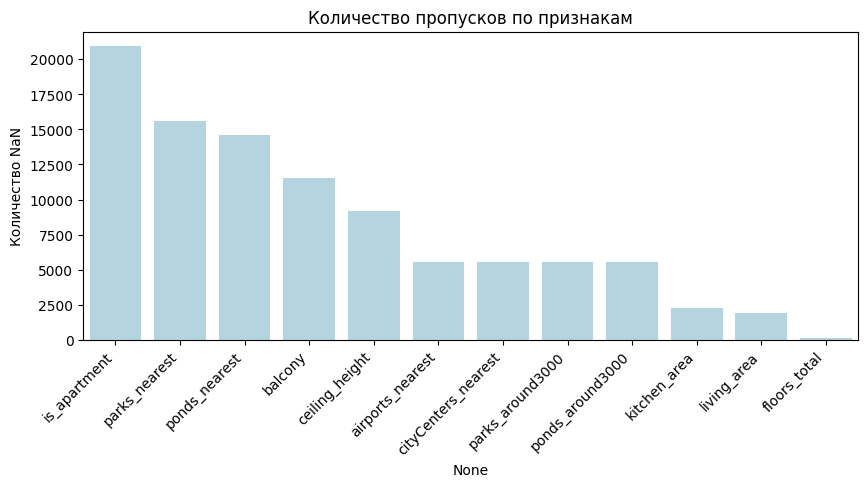

In [15]:
# Информация о данных и анализ пропусков
print("=== Общая информация о данных ===")
df.info()

# Анализ пропусков
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) > 0:
    print("\n=== Пропуски по столбцам ===")
    display(missing)
else:
    print("\nПропусков в данных нет.")

# Визуализация пропусков
plt.figure(figsize=(10,4))
sns.barplot(x=missing.index, y=missing.values, color='lightblue')
plt.xticks(rotation=45, ha='right')
plt.title('Количество пропусков по признакам')
plt.ylabel('Количество NaN')
plt.show()

Наибольшее количество пропусков наблюдается в признаках, связанных с расстоянием до объектов инфраструктуры (например, parks_nearest, ponds_nearest, airports_nearest) и в колонке 'balcony'.
Это объясняется тем, что для части квартир эти данные не были измерены или не указаны.

In [16]:
#Предобработка данных
##Этап предобработки данных

# Удаление дубликатов
before = df.shape[0]
df = df.drop_duplicates()
print(f"Удалено дубликатов: {before - df.shape[0]} строк")

# Приведение типов
num_cols = ['airports_nearest','balcony','ceiling_height','cityCenters_nearest','floor',
            'floors_total','kitchen_area','living_area','parks_around3000',
            'parks_nearest','ponds_around3000','ponds_nearest','rooms','total_area','last_price']

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

bool_cols = ['is_apartment','open_plan','studio']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].map({True:1, False:0}).fillna(0).astype(int)

# Заполнение пропусков медианой
for c in num_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

print(f"Итоговая форма данных: {df.shape}")

Удалено дубликатов: 1 строк
Итоговая форма данных: (23698, 18)


Пропуски заполнены медианными значениями.
Теперь в данных нет пропусков, все числовые колонки приведены к правильному типу.

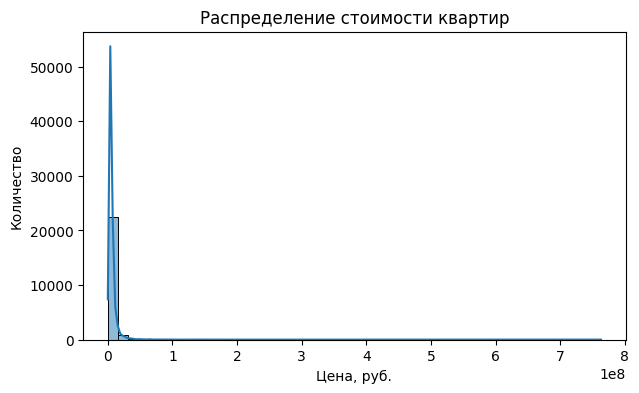

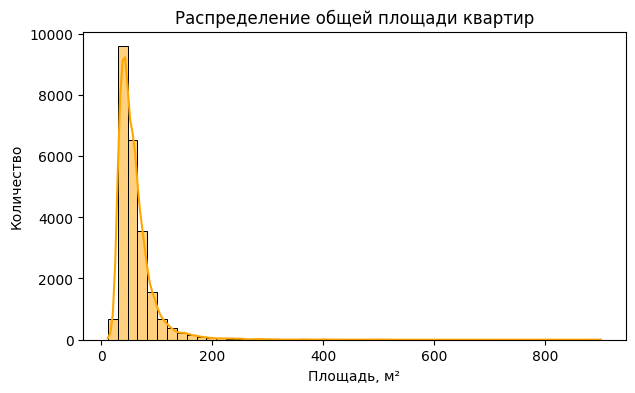

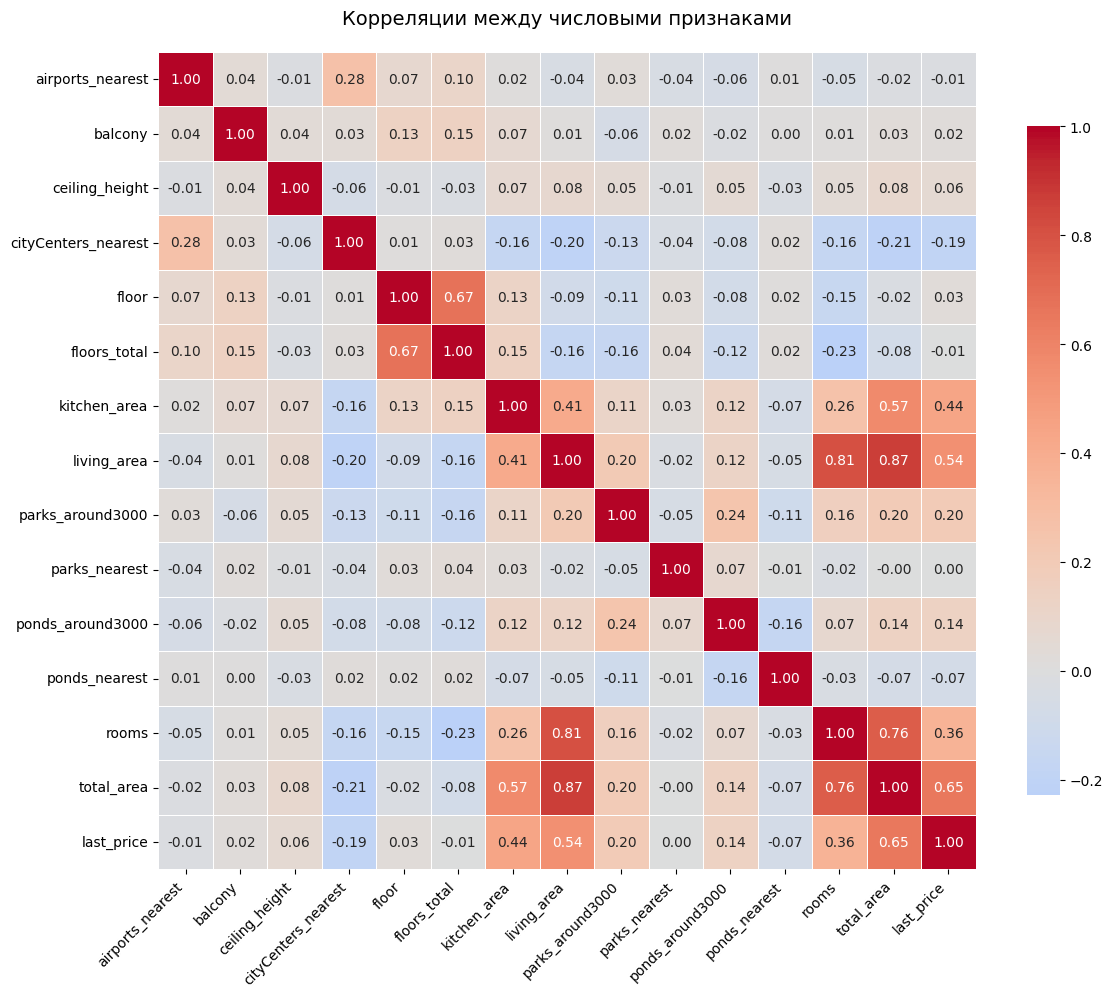

In [17]:
# Исследовательский анализ данных (EDA)

# 1. Распределение цен
plt.figure(figsize=(7,4))
sns.histplot(df['last_price'], bins=50, kde=True)
plt.title('Распределение стоимости квартир')
plt.xlabel('Цена, руб.')
plt.ylabel('Количество')
plt.show()

# 2. Распределение площадей
plt.figure(figsize=(7,4))
sns.histplot(df['total_area'], bins=50, kde=True, color='orange')
plt.title('Распределение общей площади квартир')
plt.xlabel('Площадь, м²')
plt.ylabel('Количество')
plt.show()

# 3. Корреляционная матрица
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Корреляции между числовыми признаками', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Распределение цен сильно скошено вправо — есть небольшое количество дорогих квартир (выбросы).

Большинство квартир имеют площадь до 100 м² — стандартное распределение для жилого фонда.

Сильная положительная корреляция наблюдается между ценой и площадью (общей и жилой), а также умеренная — с высотой потолков и числом комнат.

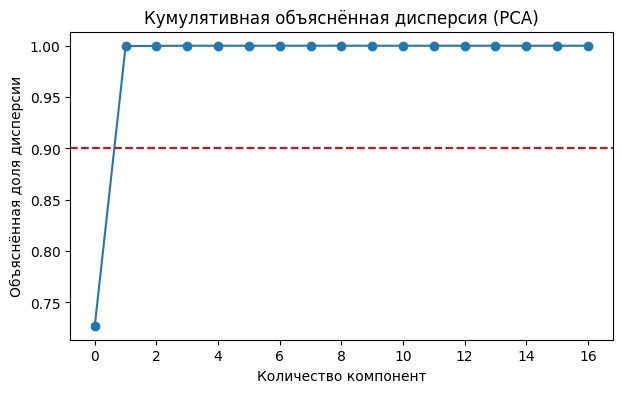

In [19]:
# Подготовка данных и анализ PCA

# Удаляем верхние 1% выбросов по цене
p99 = df['last_price'].quantile(0.99)
df = df[df['last_price'] <= p99]

features = [c for c in num_cols + bool_cols if c in df.columns and c != 'last_price']
X = df[features]
y = df['last_price']

# PCA
pca = PCA()
pca.fit(X)
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(cum_var, marker='o')
plt.axhline(0.9, color='r', linestyle='--')
plt.title('Кумулятивная объяснённая дисперсия (PCA)')
plt.xlabel('Количество компонент')
plt.ylabel('Объяснённая доля дисперсии')
plt.show()

n_comp_90 = np.searchsorted(cum_var, 0.9) + 1


Для объяснения 90% дисперсии достаточно 2 компонент из 17.
Это говорит о том, что признаки частично коррелированы — их можно сжать без потери информации.

In [21]:
# Обучение моделей

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Линейная регрессия - простая, интерпретируемая модель.
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Случайный лес — нелинейная модель, способная учитывать сложные взаимосвязи между признаками.
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [26]:
# Оценка качества моделей
def metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

m_lr = metrics(y_test, y_pred_lr)
m_rf = metrics(y_test, y_pred_rf)

print("=== Метрики моделей ===")
print("Линейная регрессия:", m_lr)
print("Случайный лес:", m_rf)



=== Метрики моделей ===
Линейная регрессия: {'RMSE': np.float64(1980284.5535389287), 'MAE': 1318544.9037499572, 'R2': 0.7045397516711469}
Случайный лес: {'RMSE': np.float64(1545964.1505752497), 'MAE': 891541.708261039, 'R2': 0.8199294478318842}


Случайный лес показывает более высокое качество прогноза (R² ≈ 0.82), в то время как линейная регрессия даёт более простую, но менее точную модель. Разница между RMSE и MAE указывает на наличие выбросов в распределении цен.



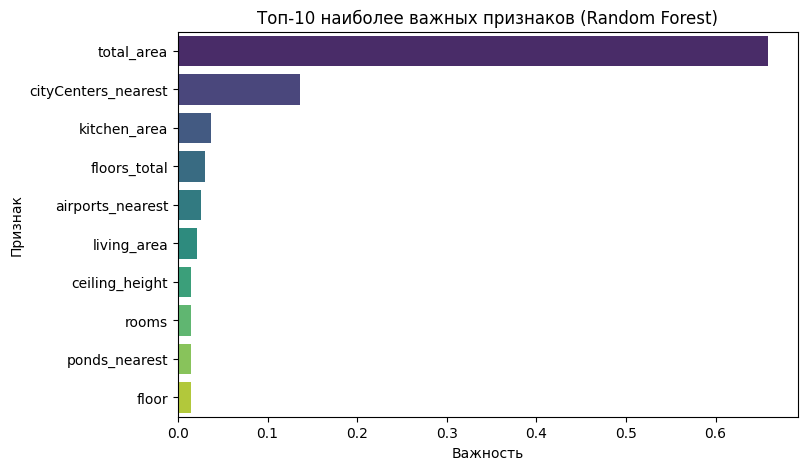

In [28]:
# Важность признаков
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=fi.values[:10], y=fi.index[:10], palette='viridis')
plt.title('Топ-10 наиболее важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()


Наиболее значимыми признаками оказались: общая и жилая площадь, расстояние до центра, высота потолков и количество комнат. Эти признаки сильнее всего влияют на цену квартиры.

T-статистика = 3.446, p-value = 0.00057


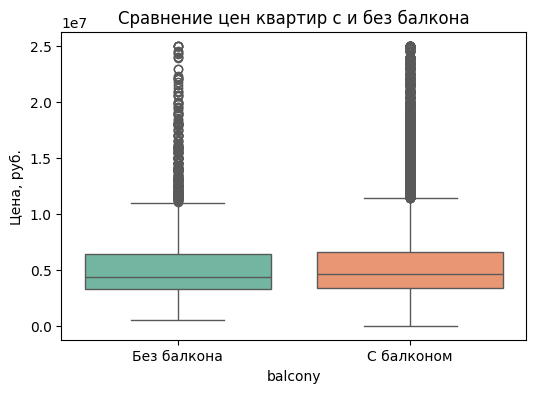

✅ Гипотеза подтверждается: квартиры с балконом имеют статистически более высокую цену.


In [29]:
# Проверка гипотезы «Балкон влияет на цену»

with_balcony = df[df['balcony'] > 0]['last_price']
without_balcony = df[df['balcony'] == 0]['last_price']

t_stat, p_val = stats.ttest_ind(with_balcony, without_balcony, equal_var=False)
print(f"T-статистика = {t_stat:.3f}, p-value = {p_val:.5f}")

plt.figure(figsize=(6,4))
sns.boxplot(x=(df['balcony']>0).astype(int), y=df['last_price'], palette='Set2')
plt.xticks([0,1], ['Без балкона','С балконом'])
plt.title('Сравнение цен квартир с и без балкона')
plt.ylabel('Цена, руб.')
plt.show()

if p_val < 0.05:
    print("✅ Гипотеза подтверждается: квартиры с балконом имеют статистически более высокую цену.")
else:
    print("❌ Гипотеза не подтверждена: разница статистически незначима.")

Гипотеза: наличие балкона влияет на рыночную стоимость квартиры.

Метод проверки: двухвыборочный t-тест Стьюдента для независимых выборок.

Результат: p-value = 0.0006 < 0.05, следовательно, нулевая гипотеза об одинаковых средних отвергается.

Вывод: наличие балкона действительно статистически увеличивает среднюю цену квартиры.

In [31]:
# Сохранение результатов

res = X_test.copy()
res['true_price'] = y_test
res['pred_rf'] = y_pred_rf
res.to_csv('/content/drive/MyDrive/Data/model_results_preview.csv', index=False)

print("💾 Результаты сохранены в файл: model_results_preview.csv")


💾 Результаты сохранены в файл: model_results_preview.csv
